In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


[CDMS ELOG](https://scdms.slac.stanford.edu/elog/CUTE+Detectors/66): The neutron source was last deployed Dec. 12th at 15:22 to Dec. 13th at 08:55 (17 hours, 33 minutes). It doesn't seem that any other source exposures occurred before the following Ge series were taken.

In [4]:
# Time frame of source exposure in Unix time
source_start = 1702412520
source_end = 1702475700

[CUTE at SNOLAB](https://arxiv.org/pdf/2310.07930): The activity of the neutron source is 37.5 kBq.\
This gives us a total of $2.369 \times 10^9$ decays during the exposure period.

Need a simulation of Cf-252 source in the CUTE geometry to tell us how many neutrons are captured in the detector.

In [5]:
ProdTag = 'CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2.'

In [6]:
filepath = np.sort(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/CDMS/CUTE/R37/Processed/Tests/{ProdTag}/Submerged/{ProdTag}_232312??_??????.root')) # Cedar

In [7]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [8]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [9]:
RQs = (["PTOFamps","PTOFchisqLF", "PTOFdelay", "EventNumber"] + 
       ['P' + label + 'S' + sequence + 'OFamps' for sequence in ['1', '2'] for label in ['A', 'B', 'C', 'D', 'E', 'F']])
df_rqs = df_filtered.AsNumpy(RQs)

Text(0, 1, 'Count / $\\mathrm{\\mu A}$')

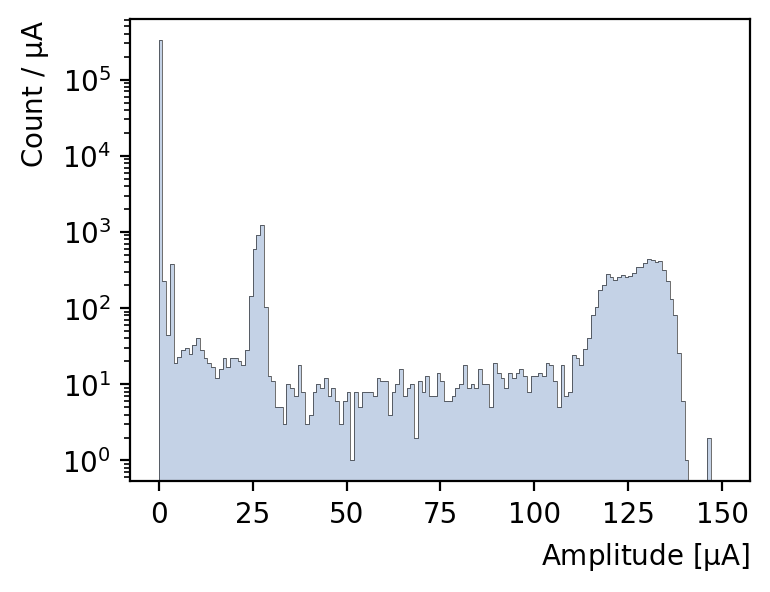

In [11]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), alpha = 0.75)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / $\mathrm{\mu A}$")

Text(0, 1, 'Count / (0.3 $\\mathrm{\\mu A}$)')

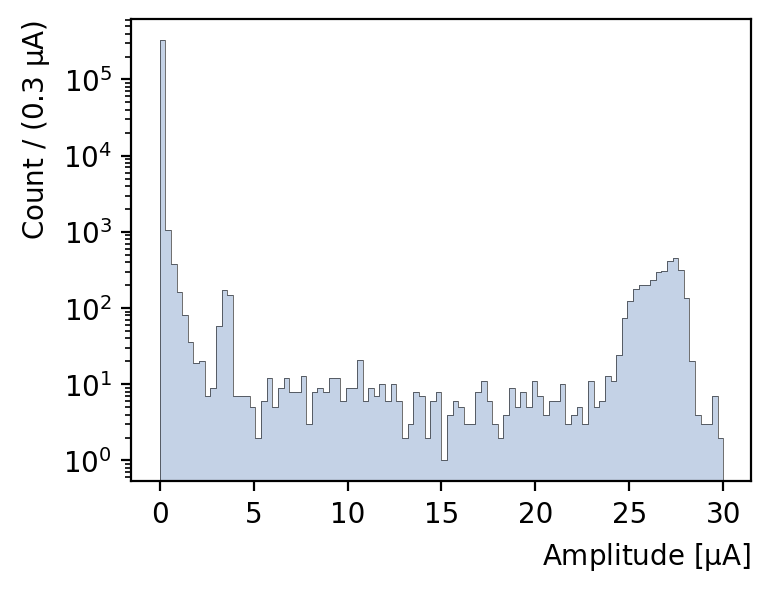

In [12]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), alpha = 0.75)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.3 $\mathrm{\mu A}$)")

In [13]:
L_peak_bins = np.linspace(2.5, 5, 51)
K_peak_bins = np.linspace(22, 30, 41)
L_peak_data = df_rqs['PTOFamps'][(df_rqs['PTOFamps'] >= 2.5e-6) & (df_rqs['PTOFamps'] <= 5e-6)] * 1e6
K_peak_data = df_rqs['PTOFamps'][(df_rqs['PTOFamps'] >= 22e-6) & (df_rqs['PTOFamps'] <= 30e-6)] * 1e6

Text(0, 1, 'Count / (0.05 $\\mathrm{\\mu A}$)')

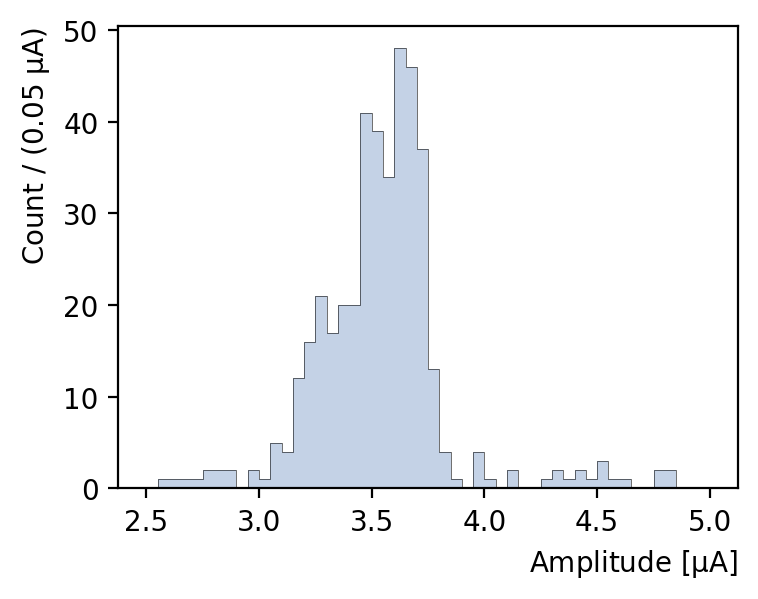

In [14]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(L_peak_data, bins=L_peak_bins, alpha = 0.75)
plt.hist(L_peak_data, bins=L_peak_bins, histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.05 $\mathrm{\mu A}$)")

Text(0, 1, 'Count / (0.2 $\\mathrm{\\mu A}$)')

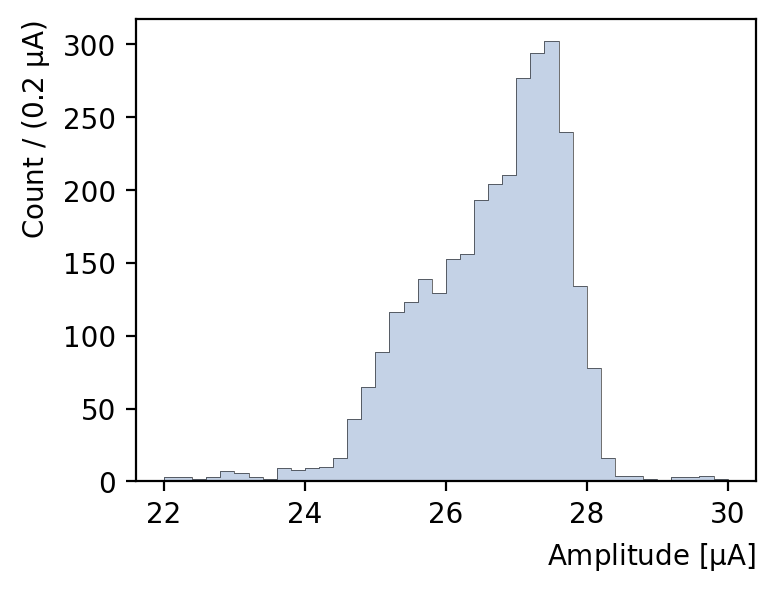

In [15]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(K_peak_data, bins=K_peak_bins, alpha = 0.75)
plt.hist(K_peak_data, bins=K_peak_bins, histtype='step', color = 'black', lw = 0.2)

plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.2 $\mathrm{\mu A}$)")

# Let's fit the k-peak with a Gaussian, a Johnson, and a flat background
$$
model = c_1 \cdot Gauss_1(\mu_1,\sigma_1) + c_2 \cdot Johnson_2(\mu_2,\lambda_2,\gamma_2,\delta_2) +  (1-c_1- c_2) \cdot Uniform
$$

In [16]:
# make a frame
def make_frame(obs, *objects):
    frame = obs.frame()
    for obj in objects:
        obj.plotOn(frame)
    return frame

# draw a frame
def make_plot(frame):
    c = ROOT.TCanvas()
    frame.Draw()
    c.Draw()
    # need this for the plot not to be removed!
    ROOT.SetOwnership( c, False )

In [17]:
counts, bin_edges = np.histogram(K_peak_data, bins=K_peak_bins)
binWidth = np.diff(K_peak_bins)[0]
bin_centers = bin_edges[:-1] + binWidth / 2
counts_err = np.sqrt(counts)

# Observable
x = ROOT.RooRealVar("x", "x", 22, 30)

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 26, 22, 30)
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", 1, 0.1, 10)
# Parameters
mean_2 = ROOT.RooRealVar("#mu2", "#mu", 27.5, 24, 30)
lambda_2 = ROOT.RooRealVar("#lambda2", "#lambda", 1, 0.1, 4)
delta_2 = ROOT.RooRealVar("#delta2", "#delta", 4, 0.1, 5)
gamma_2 = ROOT.RooRealVar("#gamma2", "#gamma", 3, 0.1, 5)

# Distributions
g1 = ROOT.RooGaussian("g1", "g1", x, mean_1, sigma_1)
j2 = ROOT.RooJohnson("j2", "j2", x, mean_2, lambda_2, gamma_2, delta_2)
flat = ROOT.RooUniform("flat", "flat", x)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.5, 0.0, 1.0)
frac2 = ROOT.RooRealVar("c2", "#c", 0.2, 0.0, 1.0)

# Convert numpy array into RooFit object
pdf = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(g1, j2, flat), ROOT.RooArgList(frac1, frac2))
# 
#data = ROOT.RooDataSet.from_numpy({"x": K_peak_data},[x],name='2_gauss',title='2_gauss')
data = ROOT.RooDataHist.from_numpy(counts, [x], bins=[K_peak_bins])

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #delta2      4.00000e+00  4.90000e-01    1.00000e-01  5.00000e+00
     2 #gamma2      3.00000e+00  4.90000e-01    1.00000e-01  5.00000e+00
     3 #lambda2     1.00000e+00  3.90000e-01    1.00000e-01  4.00000e+00
     4 #mu1         2.60000e+01  8.00000e-01    2.20000e+01  3.00000e+01
     5 #mu2         2.75000e+01  6.00000e-01    2.40000e+01  3.00000e+01
     6 #sigma1      1.00000e+00  4.50000e-01    1.00000e-01  1.00000e+01
     7 c1           5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     8 c2           2.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 

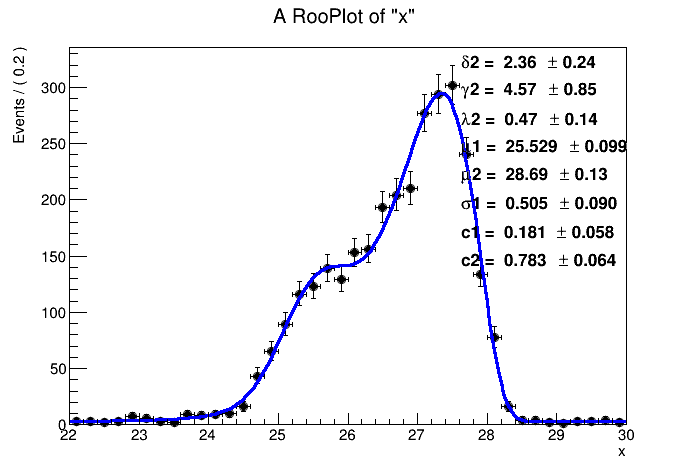

In [18]:
nll = pdf.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = make_frame(x,data,pdf)

pdf.paramOn(frame)
make_plot(frame)

In [19]:
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(K_peak_data))
sum_frac1_frac2 = ROOT.RooFormulaVar("sum_c1_c2", "@0 + @1", ROOT.RooArgList(frac1, frac2))
signal = ROOT.RooProduct("event yield", "nevent * (frac1 + frac2)", ROOT.RooArgList(nevent, sum_frac1_frac2))

print(f'The number of events in the peak is {signal.getVal():.1f} with error {signal.getPropagatedError(fit_result):.1f}')

The number of events in the peak is 2954.6 with error 26.7


In [20]:
def gauss(x, mu1, sigma1):
    return 1 / np.sqrt(2 * np.pi * sigma1**2) * np.exp( -(x - mu1)**2 / (2 * sigma1**2) )

def johnson(x, mu2, lambda2, gamma2, delta2):
    return delta2 / (lambda2 * np.sqrt(2 * np.pi)) * 1/np.sqrt(1 + ( (x - mu2) / lambda2 )**2 ) * np.exp( -1/2 * (gamma2 + delta2 * np.arcsinh( (x - mu2) / lambda2) )**2 )

def uniform(x, xrange):
    return 1.0 / xrange

def gauss_johnson_flat(x, c1, c2, mu1, sigma1, mu2, lambda2, gamma2, delta2, xrange):
    gauss1 = gauss(x, mu1, sigma1)
    johnson2 = johnson(x, mu2, lambda2, gamma2, delta2)
    flat = uniform(x, xrange)

    PDF = c1 * gauss1 + c2 * johnson2 + (1 - c1 - c2) * flat

    return PDF

In [21]:
x_plot = np.linspace(22, 30, 101)
mu1, mu1_err, mu2, mu2_err = mean_1.getVal(), mean_1.getError(), mean_2.getVal(), mean_2.getError()
sigma1, sigma1_err = sigma_1.getVal(), sigma_1.getError()
delta2, delta2_err = delta_2.getVal(), delta_2.getError()
gamma2, gamma2_err = gamma_2.getVal(), gamma_2.getError()
lambda2, lambda2_err = lambda_2.getVal(), lambda_2.getError()
c1, c1_err, c2, c2_err = frac1.getVal(), frac1.getError(), frac2.getVal(), frac2.getError()
xrange = max(K_peak_bins) - min(K_peak_bins)

PDF = np.array([gauss_johnson_flat(i, c1, c2, mu1, sigma1, mu2, lambda2, gamma2, delta2, xrange) for i in x_plot])

In [22]:
obs = counts[9:-7]
obs_err = counts_err[9:-7]
exp = np.array([gauss_johnson_flat(i, c1, c2, mu1, sigma1, mu2, lambda2, gamma2, delta2, xrange) for i in bin_centers[9:-7]]) * binWidth * sum(counts)
ddof = 8
chi2 = sum( (obs - exp)**2 / obs_err**2 ) / (len(obs) - ddof)
print(chi2)

1.2771112870814836


(0.0, 375.0)

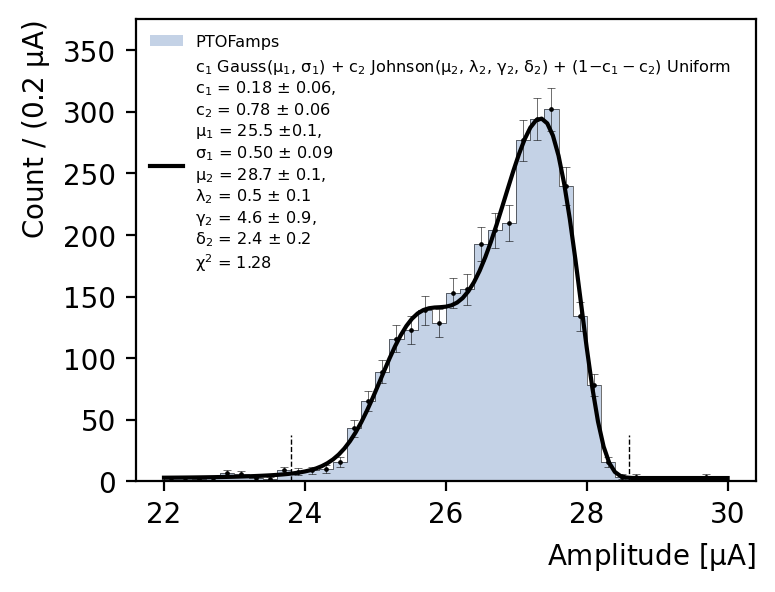

In [23]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(K_peak_data, bins=K_peak_bins, label = 'PTOFamps', alpha = 0.75)
plt.hist(K_peak_data, bins=K_peak_bins, histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.2 $\mathrm{\mu A}$)")

plt.plot(x_plot, PDF*len(K_peak_data)*np.diff(K_peak_bins)[0], color = 'black', 
         label = r'$\mathrm{c_1}$ Gauss($\mathrm{\mu_1}$, $\mathrm{\sigma_1}$) + $\mathrm{c_2}$ Johnson($\mathrm{\mu_2}$, $\mathrm{\lambda_2}$, $\mathrm{\gamma_2}$, $\mathrm{\delta_2}$) + (1$\mathrm{- c_1 - c_2}$) Uniform' + 
           '\n'+r'$\mathrm{c_1}$' + f' = {c1:.2f} '+r'$\pm$'+f' {c1_err:.2f}, ' + 
           '\n'+r'$\mathrm{c_2}$' + f' = {c2:.2f} ' + r'$\pm$'+f' {c2_err:.2f}' +
           '\n'+r'$\mathrm{\mu_1}$'+f' = {mu1:.1f} '+ r'$\pm$'+f'{mu1_err:.1f}, ' + 
           '\n'+r'$\mathrm{\sigma_1}$'+f' = {sigma1:.2f} '+r'$\pm$'+f' {sigma1_err:.2f}' +
           '\n'+r'$\mathrm{\mu_2}$'+f' = {mu2:.1f} '+r'$\pm$'+f' {mu2_err:.1f}, ' + 
           '\n'+r'$\mathrm{\lambda_2}$'+f' = {lambda2:.1f} '+r'$\pm$'+f' {lambda2_err:.1f}'
           '\n'+r'$\mathrm{\gamma_2}$'+f' = {gamma2:.1f} '+r'$\pm$'+f' {gamma2_err:.1f},'
           '\n'+r'$\mathrm{\delta_2}$'+f' = {delta2:.1f} '+r'$\pm$'+f' {delta2_err:.1f}'
           '\n'+r'$\mathrm{\chi^2}$ = '+f'{np.round(chi2, 2)}')

plt.errorbar(bin_centers, counts, yerr = counts_err, ls = "None", color='black', capsize = 1.5, elinewidth=0.2, capthick = 0.2)
plt.scatter(bin_centers, counts, color = 'black', s = 0.5)
plt.axvline(bin_centers[9] - binWidth / 2, 0, 0.1, lw = 0.5, color = 'black', ls = '--')
plt.axvline(bin_centers[-8] + binWidth / 2, 0, 0.1, lw = 0.5, color = 'black', ls = '--')

plt.legend(fontsize = 5.8, loc = 'upper left')

plt.ylim(0, 375)

# Let's fit the L-peak with a skewed Gaussian and a flat background
$$
model = c_1 \cdot Johnson(\mu_1,\sigma_1,) + (1-c_1) \cdot Uniform
$$

In [24]:
counts, bin_edges = np.histogram(L_peak_data, bins=L_peak_bins)
binWidth = np.diff(L_peak_bins)[0]
bin_centers = bin_edges[:-1] + binWidth / 2
counts_err = np.sqrt(counts)
counts_err[counts_err == 0] = np.inf

# Observable
x = ROOT.RooRealVar("x", "x", 2.5, 5)

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 3.5, 2, 6)
lambda_1 = ROOT.RooRealVar("#lambda1", "#lambda", 1, 0.1, 4)
delta_1 = ROOT.RooRealVar("#delta1", "#delta", 4, 0.1, 5)
gamma_1 = ROOT.RooRealVar("#gamma1", "#gamma", 3, 0.1, 5)

# Distributions
j1 = ROOT.RooJohnson("j1", "j1", x, mean_1, lambda_1, gamma_1, delta_1)
flat = ROOT.RooUniform("flat", "flat", x)

# Weights of distributions
frac1 = ROOT.RooRealVar("c1", "c", 0.5, 0.0, 1.0)

# Weighted sum of distributions
pdf = ROOT.RooAddPdf("model", "model", [j1, flat], [frac1])
# Convert numpy array into RooFit object
#data = ROOT.RooDataSet.from_numpy({"x": L_peak_data},[x],name='1_Johnson',title='1_Johnson')
data = ROOT.RooDataHist.from_numpy(counts, [x], bins=[L_peak_bins])

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #delta1      4.00000e+00  4.90000e-01    1.00000e-01  5.00000e+00
     2 #gamma1      3.00000e+00  4.90000e-01    1.00000e-01  5.00000e+00
     3 #lambda1     1.00000e+00  3.90000e-01    1.00000e-01  4.00000e+00
     4 #mu1         3.50000e+00  4.00000e-01    2.00000e+00  6.00000e+00
     5 c1           5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        2500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=283.658 

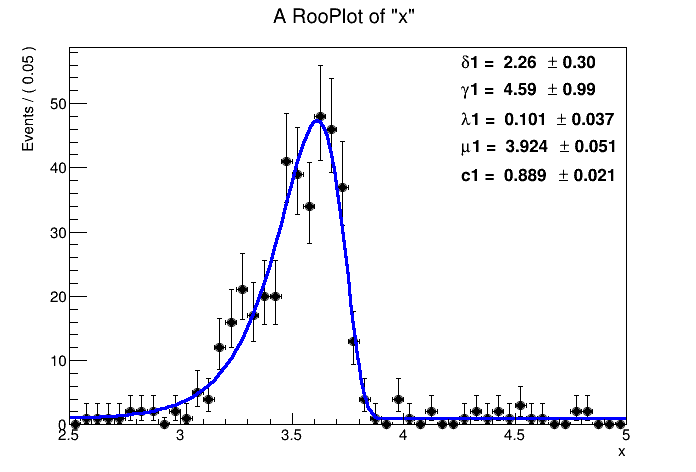

In [25]:
nll = pdf.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()
fit_result = m.save()

frame = make_frame(x,data,pdf)

pdf.paramOn(frame)
make_plot(frame)

In [26]:
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(L_peak_data))
signal = ROOT.RooProduct("event yield", "nevent * frac1", ROOT.RooArgList(nevent, frac1))

print(f'The number of events in the peak is {signal.getVal():.1f} with error {signal.getPropagatedError(fit_result):.1f}')

The number of events in the peak is 367.9 with error 8.7


In [27]:
def johnson_flat(x, c1, mu1, lambda1, gamma1, delta1, xrange):
    Johnson1 = (delta1 / (lambda1 * np.sqrt(2 * np.pi)) * 1/np.sqrt(1 + ( (x - mu1) / lambda1 )**2 ) * np.exp( -1/2 * (gamma1 + delta1 * np.arcsinh( (x - mu1) / lambda1) )**2 ))
    flat = 1.0 / xrange

    PDF = c1 * Johnson1 + (1 - c1) * flat

    return PDF

In [28]:
x_plot = np.linspace(2.5, 5, 101)
delta1, delta1_err = delta_1.getVal(), delta_1.getError()
gamma1, gamma1_err = gamma_1.getVal(), gamma_1.getError()
lambda1, lambda1_err = lambda_1.getVal(), lambda_1.getError()
mu1, mu1_err = mean_1.getVal(), mean_1.getError()
c1, c1_err = frac1.getVal(), frac1.getError()
xrange = max(L_peak_bins) - min(L_peak_bins)

PDF = np.array([johnson_flat(i, c1, mu1, lambda1, gamma1, delta1, xrange) for i in x_plot])

In [29]:
obs = counts[6:-22]
obs_err = counts_err[6:-22]
exp = np.array([johnson_flat(i, c1, mu1, lambda1, gamma1, delta1, xrange) for i in bin_centers[6:-22]]) * binWidth * sum(counts)
ddof = 5
chi2 = sum( (obs - exp)**2 / obs_err**2 ) / (len(obs) - ddof - 1) # subtracting one to exclude 0 bin
print(chi2)

1.6667217423671161


(0.0, 70.0)

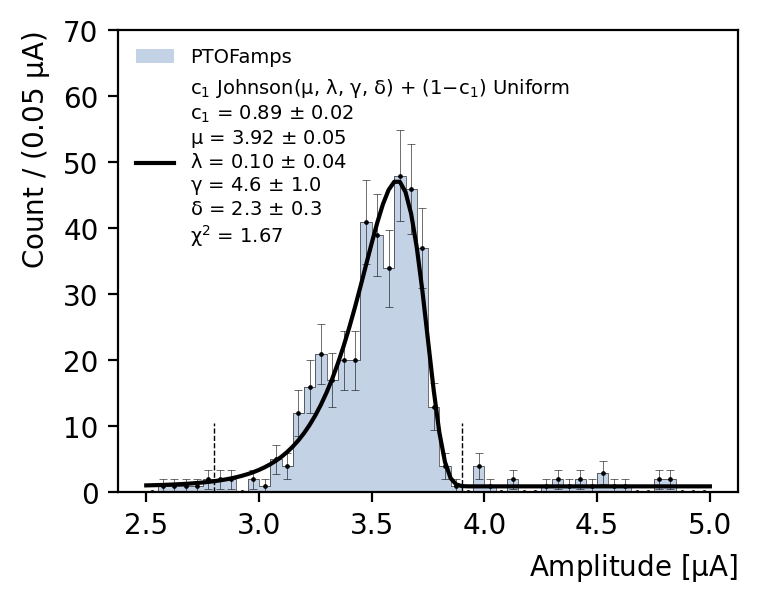

In [30]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(L_peak_data, bins=L_peak_bins, label = 'PTOFamps', alpha = 0.75)
plt.hist(L_peak_data, bins=L_peak_bins, histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.05 $\mathrm{\mu A}$)")


plt.plot(x_plot, PDF*len(L_peak_data)*np.diff(L_peak_bins)[0], color = 'black', 
         label = r'$\mathrm{c_1}$ Johnson($\mathrm{\mu}$, $\mathrm{\lambda}$, $\mathrm{\gamma}$, $\mathrm{\delta}$) + (1$\mathrm{- c_1}$) Uniform' + 
          '\n' + r'$\mathrm{c_1}$' + f' = {c1:.2f} ' + r'$\pm$' + f' {c1_err:.2f}'
          '\n' + r'$\mathrm{\mu}$' + f' = {mu1:.2f} ' + f'$\pm$' + f' {mu1_err:.2f}'
          '\n' + r'$\mathrm{\lambda}$' + f' = {lambda1:.2f} ' + r'$\pm$' + f' {lambda1_err:.2f}'
          '\n' + r'$\mathrm{\gamma}$' + f' = {gamma1:.1f} ' + r'$\pm$' + f' {gamma1_err:.1f}'
          '\n' + r'$\mathrm{\delta}$' + f' = {delta1:.1f} ' + r'$\pm$' + f' {delta1_err:.1f}'
          '\n' + r'$\mathrm{\chi^2}$ = ' + f'{np.round(chi2, 2)}')

plt.errorbar(bin_centers, counts, yerr = np.sqrt(counts), ls = "None", color='black', capsize = 1.5, elinewidth=0.2, capthick = 0.2)
plt.scatter(bin_centers, counts, color = 'black', s = 0.5)

plt.axvline(bin_centers[6] - binWidth / 2, 0, 0.15, lw = 0.5, color = 'black', ls='--')
plt.axvline(bin_centers[-23] + binWidth / 2, 0, 0.15, lw = 0.5, color = 'black', ls='--')

plt.legend(fontsize = 7, loc = 'upper left')

plt.ylim(0, 70)